# Topic 1

## Theory Questions:
What is the purpose of thresholding in image processing?
- Turn a grayscale image into binary image

When would you prefer adaptive thresholding over global thresholding?
- When an image suffers from uneven illumination

Explain how Otsu's method determines the optimal threshold.
- It tries to find the threshold that maximizes a given metric which seperates the image best into foreground and background.

What does `THRESH_BINARY_INV` do, and when would you use it?
- It does the inverse of what `THRESH_BINARY` does which means it makes a pixel black when it exceeds a certain threshold. It is useful when you want the reverse of what `THRESH_BINARY` normally does.

What kind of histogram does Otsu's method work best on?
- One with two distinct peaks

## Coding Task 1

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def show_img(img):
    cv2.imshow('img', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

In [3]:
def show_imgs(imgs):
    for i, img in enumerate(imgs):
        cv2.imshow(f'img{i}', img)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

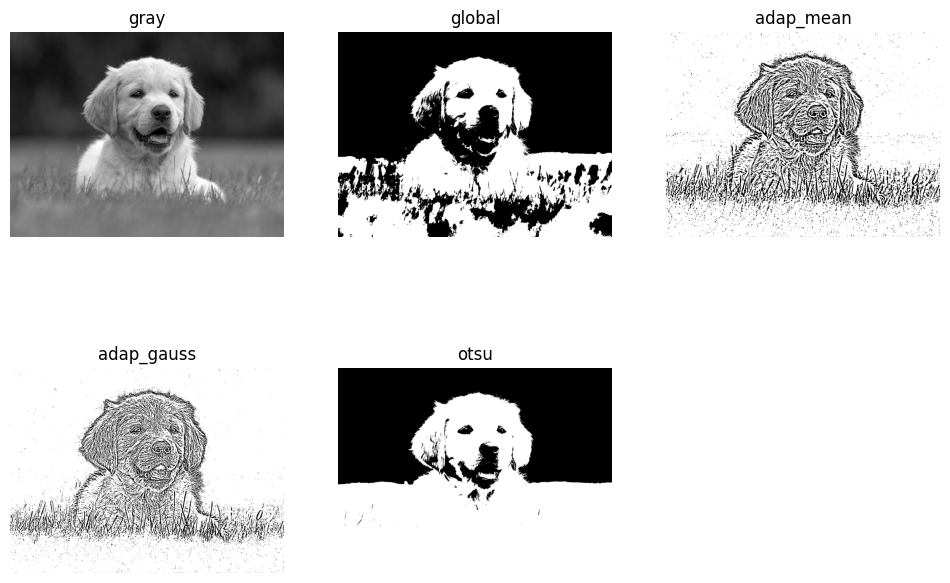

In [4]:
# Import img
img = cv2.imread('images/image1.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Global Thresh
T = 120
_, global_thresh = cv2.threshold(gray, T, 255, cv2.THRESH_BINARY)

# Adaptive Thresh
adaptive_thresh_mean = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, 11, 2)
adaptive_thresh_gauss = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# Otsu
_, thresh_otsu = cv2.threshold(
gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

titles = [
    'gray', 'global', 'adap_mean', 'adap_gauss', 'otsu'
]
imgs = [
    gray, global_thresh, adaptive_thresh_mean, adaptive_thresh_gauss, thresh_otsu
]

plt.figure(figsize=(12, 8))
for i in range(5):
    plt.subplot(2, 3, i+1)
    plt.imshow(imgs[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')

plt.show()

# Topic 2

## Theoretical Questions
What is a structuring element?
- The shape of the kernel that is used to apply a certain operation on the image

Explain the difference between erosion and dilation with a visual example.
- Erosion is the shrinking of details. It sets the pixel value to the minimum value in the current kernel.
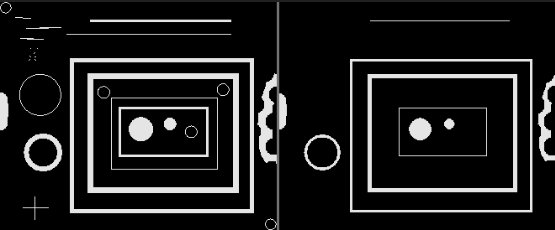
- Dialation is the expansion of details. It sets the pixel value to the maximum value in the current kernel.
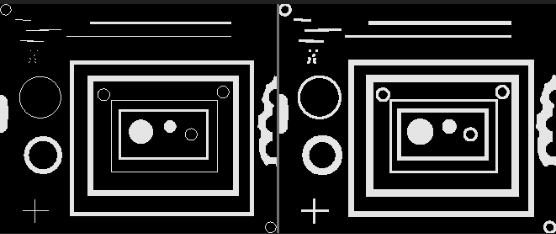

When would you use Opening vs Closing?
- Open: Removes noise from an image / Breaking thin connections between objects / Smoothing
- Close: Filling small holes without changing it overall area much

How does morphological gradient relate to edge detection?
- Because only the thin white lines that were the difference between the expansion of dialation and the shrinkage of erosion that remain which leaves an outline of the objects in the image.

What happens if you apply dilation many times on a binary image?
- Most holes would fill up, lines would get much thicker and objects become bigger.

## Coding Task 2

In [ ]:
# Try to erode, dialate, open, close
# Try to use different structuring elements

# Load image
gray = cv2.imread('images/image1.jpg', cv2.IMREAD_GRAYSCALE)
# plt.imshow(raw, cmap='gray')


# structuring elements
square = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
corss = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))

# Erosion
gray_erode = cv2.erode(gray, square, iterations=1)

# Dialation
gray_dialate = cv2.dilate(gray, square, iterations=1)

# Open
gray_open = cv2.morphologyEx(gray, cv2.MORPH_OPEN, square)

# Close
gray_close = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, square)


titles = [
    'Gray', 'Gray_Erode', 'Gray_Dialate', 'Gray_Open', 'Gray_Close'
]

imgs = [
    gray, gray_erode, gray_dialate, gray_open, gray_close
]

for i, img in enumerate(imgs):
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.axis('off')
